# Richard Kwan

## Assignment 03, Problem 2

Building an image classifier for Fashion MNIST with PyTorch, rebuilt step by
step from the section "Building an Image Classifier with PyTorch" in
`10_neural_nets_with_pytorch.ipynb`. The cells are in execution order: run
them from top to bottom.

## 1. Setup: imports and device selection

Import PyTorch, its neural-network module `nn`, TorchVision (datasets and
transforms), TorchMetrics (accuracy) and Matplotlib (plots). Then pick the
fastest available device: an NVIDIA GPU (`cuda`), then Apple Silicon (`mps`),
otherwise the CPU.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"torch {torch.__version__}, torchvision {torchvision.__version__}, "
      f"torchmetrics {torchmetrics.__version__}")
print(f"Using device: {device}")

torch 2.14.0+cu130, torchvision 0.29.0+cu130, torchmetrics 1.9.0
Using device: cpu


## 2. Load the data

Download Fashion MNIST into `datasets/`. The transform converts each image to
a `float32` tensor with pixel values scaled to the range 0–1. The 60,000
training images are split into 55,000 for training and 5,000 for validation
(seed 42), and the 10,000 test images are kept separate. Each set gets a
`DataLoader` with batches of 32; only the training loader is shuffled.

In [2]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

classes = train_and_valid_data.classes
print(f"train: {len(train_data)}, valid: {len(valid_data)}, "
      f"test: {len(test_data)}")
X_batch, y_batch = next(iter(train_loader))
print(f"batch shapes: X {tuple(X_batch.shape)}, y {tuple(y_batch.shape)}")

train: 55000, valid: 5000, test: 10000
batch shapes: X (32, 1, 28, 28), y (32,)


## 3. Inspect the data

Each sample is an `(image, target)` tuple. The image has the shape
`[channels, rows, columns]`: grayscale Fashion MNIST images have 1 channel and
28×28 pixels. Print the first training sample's shape, dtype and class name.

In [3]:
X_sample, y_sample = train_data[0]
print(f"shape: {tuple(X_sample.shape)}")
print(f"dtype: {X_sample.dtype}")
print(f"class: {classes[y_sample]}")

shape: (1, 28, 28)
dtype: torch.float32
class: Ankle boot


Plot the first 10 training images with their class names. `squeeze(0)`
drops the channel dimension so Matplotlib can draw each image.

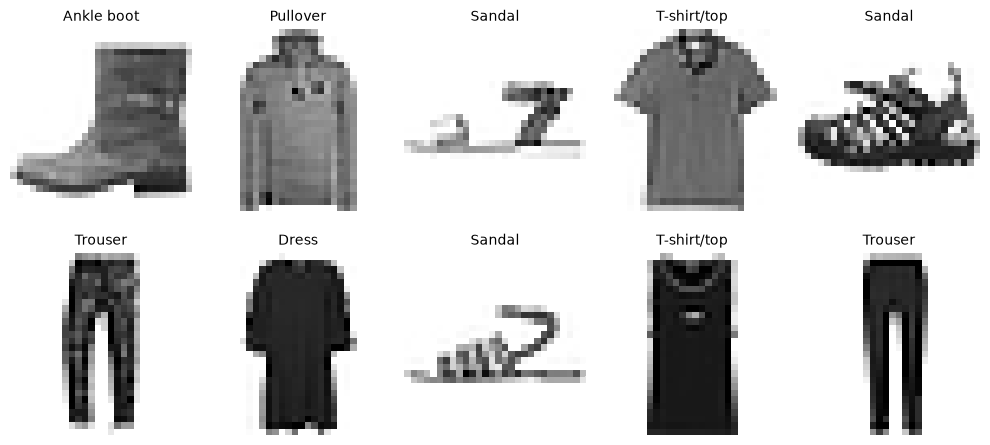

In [4]:
n_rows, n_cols = 2, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2.4))
for index, ax in enumerate(axes.flat):
    X, y = train_data[index]
    ax.imshow(X.squeeze(0), cmap="binary")
    ax.set_title(classes[y], fontsize=10)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 4. Build the model

`ImageClassifier` is a multilayer perceptron: it flattens each 1×28×28 image
into 784 inputs, then applies two hidden layers (300 and 100 neurons, ReLU
activations) and an output layer with one logit per class (10). The layer
sizes are arguments so the class can be reused with other sizes. The model is
created with seed 42 and moved to the device. `CrossEntropyLoss` takes the
raw logits and the class indices.

In [5]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)


torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()
model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

## 5. Training and evaluation helpers

`evaluate_tm` computes a TorchMetrics metric over a data loader in evaluation
mode, without gradients. `train2` runs the training loop and returns a history
with one entry per epoch:

- `train_losses`: mean training loss
- `train_metrics`: training accuracy (averaged while the model is learning)
- `valid_metrics`: validation accuracy at the end of the epoch

In [6]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end


def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

## 6. Train the model

Train for 20 epochs with SGD (learning rate 0.1), measuring multiclass
accuracy. Then save the history to `outputs/history.json` and the trained
weights (the `state_dict`) to `outputs/fashion_mnist_weights.pt`. This takes a
few minutes on a CPU.

In [7]:
n_epochs = 20
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train2(model, optimizer, xentropy, accuracy, train_loader,
                 valid_loader, n_epochs)

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
history_path = output_dir / "history.json"
weights_path = output_dir / "fashion_mnist_weights.pt"
history_path.write_text(json.dumps(history, indent=2))
torch.save(model.state_dict(), weights_path)
print(f"saved {history_path} and {weights_path}")

Epoch 1/20, train loss: 0.6060, train metric: 0.7814, valid metric: 0.8424


Epoch 2/20, train loss: 0.4061, train metric: 0.8496, valid metric: 0.8402


Epoch 3/20, train loss: 0.3630, train metric: 0.8661, valid metric: 0.8494


Epoch 4/20, train loss: 0.3355, train metric: 0.8768, valid metric: 0.8638


Epoch 5/20, train loss: 0.3154, train metric: 0.8829, valid metric: 0.8782


...

Epoch 16/20, train loss: 0.2078, train metric: 0.9196, valid metric: 0.8886


Epoch 17/20, train loss: 0.2033, train metric: 0.9233, valid metric: 0.8870


Epoch 18/20, train loss: 0.1991, train metric: 0.9230, valid metric: 0.8846


Epoch 19/20, train loss: 0.1916, train metric: 0.9266, valid metric: 0.8812


Epoch 20/20, train loss: 0.1876, train metric: 0.9286, valid metric: 0.8788
saved outputs/history.json and outputs/fashion_mnist_weights.pt


## 7. Plot the training accuracy

Plot training and validation accuracy per epoch and save the figure as
`training_accuracy.png`. The training accuracy is averaged over each epoch
while the model is still learning, so it is plotted half an epoch earlier than
the validation accuracy, which is measured at the end of the epoch.

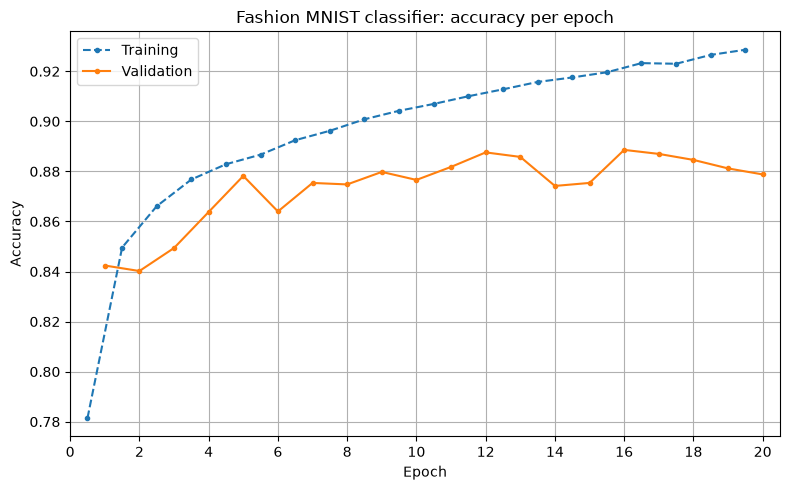

final train accuracy: 0.9286, final valid accuracy: 0.8788, best valid accuracy: 0.8886 (epoch 16)


In [8]:
train_acc = history["train_metrics"]
valid_acc = history["valid_metrics"]
epochs = np.arange(n_epochs)

plt.figure(figsize=(8, 5))
plt.plot(epochs + 0.5, train_acc, ".--", label="Training")
plt.plot(epochs + 1.0, valid_acc, ".-", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xlim(0, n_epochs + 0.5)
plt.xticks(range(0, n_epochs + 1, 2))
plt.grid()
plt.title("Fashion MNIST classifier: accuracy per epoch")
plt.legend()
plt.tight_layout()
plt.savefig("training_accuracy.png")
plt.show()

print(f"final train accuracy: {train_acc[-1]:.4f}, "
      f"final valid accuracy: {valid_acc[-1]:.4f}, "
      f"best valid accuracy: {max(valid_acc):.4f} "
      f"(epoch {int(np.argmax(valid_acc)) + 1})")

## 8. Make predictions

Load the saved weights into a new `ImageClassifier`, then predict the first 3
validation images. The predicted class is the one with the largest logit.
Compare the predicted and true class names.

In [9]:
loaded_model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300,
                               n_hidden2=100, n_classes=10).to(device)
loaded_model.load_state_dict(torch.load(weights_path, map_location=device))

loaded_model.eval()
X_new, y_new = next(iter(valid_loader))
X_new, y_new = X_new[:3].to(device), y_new[:3]
with torch.no_grad():
    y_pred_logits = loaded_model(X_new)
y_pred = y_pred_logits.argmax(dim=1).cpu()  # index of the largest logit

for i, (pred, true) in enumerate(zip(y_pred, y_new)):
    mark = "correct" if pred == true else "WRONG"
    print(f"image {i}: predicted {classes[pred]:<12} "
          f"true {classes[true]:<12} ({mark})")

image 0: predicted Sneaker      true Sneaker      (correct)
image 1: predicted Coat         true Coat         (correct)
image 2: predicted Pullover     true Pullover     (correct)


Softmax turns the logits into class probabilities (one row per image, one
column per class). The results are moved to the CPU because `round()` is not
supported on MPS.

In [10]:
y_proba = F.softmax(y_pred_logits, dim=1).cpu()
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8590, 0.0000,
         0.1410],
        [0.0000, 0.0000, 0.0070, 0.0000, 0.9930, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0040, 0.0000, 0.5920, 0.0000, 0.2120, 0.0000, 0.1910, 0.0000, 0.0010,
         0.0000]])

The top-4 probabilities: `torch.topk` picks the 4 largest logits per image,
and softmax is applied to just those 4.

In [11]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1).cpu()
for i, (indices, probas) in enumerate(zip(y_top4_indices.cpu(),
                                          y_top4_probas)):
    top4 = ", ".join(f"{classes[index]} {proba:.3f}"
                     for index, proba in zip(indices, probas))
    print(f"image {i}: {top4}")

image 0: Sneaker 0.859, Ankle boot 0.141, Sandal 0.000, Trouser 0.000
image 1: Coat 0.993, Pullover 0.007, Shirt 0.000, Bag 0.000
image 2: Pullover 0.593, Coat 0.212, Shirt 0.192, T-shirt/top 0.004


## 9. Count the model parameters

Print each layer's weights and biases with their shape and count, then the
total. Most parameters are in the first layer, which connects all 784 pixels
to each of the 300 neurons.

In [12]:
for name, param in model.named_parameters():
    print(f"{name:<14} {str(tuple(param.shape)):<12} {param.numel():>8,}")

n_params = sum(param.numel() for param in model.parameters())
print(f"total parameters: {n_params:,}")

mlp.1.weight   (300, 784)    235,200
mlp.1.bias     (300,)            300
mlp.3.weight   (100, 300)     30,000
mlp.3.bias     (100,)            100
mlp.5.weight   (10, 100)       1,000
mlp.5.bias     (10,)              10
total parameters: 266,610
